In [1308]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib

In [1309]:
df = pd.read_csv('obesity.csv')

In [1310]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [1311]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [1312]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [1313]:
df.dtypes

Gender             object
Age               float64
Height            float64
Weight            float64
family_history     object
FAVC               object
FCVC              float64
NCP               float64
CAEC               object
SMOKE              object
CH2O              float64
SCC                object
FAF               float64
TUE               float64
CALC               object
MTRANS             object
Obesity            object
dtype: object

In [1314]:
df.shape

(2111, 17)

### Gender

In [1315]:
list_gender = ['Female', 'Male']
df = df[df['Gender'].isin(list_gender)]

In [1316]:
result = df.groupby('Gender').mean(numeric_only=True)
print(result)

              Age    Height     Weight      FCVC       NCP      CH2O  \
Gender                                                                 
Female  24.001907  1.643298  82.302364  2.567319  2.632419  1.941083   
Male    24.616020  1.758690  90.769478  2.274238  2.737592  2.073373   

             FAF       TUE  
Gender                      
Female  0.847137  0.647227  
Male    1.169639  0.668256  


### Age

In [1317]:
df['Age'] = df['Age'].astype(int)
df = df[df['Age'].between(14, 61)]

In [1318]:
result = df.groupby('Age').mean(numeric_only=True)
print(result)

       Height      Weight      FCVC       NCP      CH2O       FAF       TUE
Age                                                                        
14   1.710000   72.000000  3.000000  3.000000  3.000000  2.000000  1.000000
15   1.650000   86.000000  3.000000  3.000000  1.000000  3.000000  2.000000
16   1.672579   58.168463  2.266900  2.139695  1.924794  1.246791  1.046658
17   1.727922   64.430676  2.314308  3.085766  1.977758  1.382709  0.976761
18   1.706174   78.174598  2.340292  2.782143  1.898111  1.087706  0.907443
19   1.689859   71.231318  2.434339  2.778872  2.002737  1.360757  0.745450
20   1.701998   88.262237  2.540378  2.720579  1.941667  1.154155  0.755342
21   1.693258   86.386153  2.386813  2.532730  2.117461  1.170815  0.621706
22   1.708292   82.430610  2.326974  2.511659  2.092235  1.047323  0.800260
23   1.703705   84.108503  2.321457  2.677111  2.077421  1.033085  0.823793
24   1.698987   95.365826  2.387197  2.611976  2.079641  0.837696  0.635230
25   1.69454

### Height

In [1319]:
df['Height'] = df['Height'].round(2)
df = df[df['Height'].between(1.45, 1.98)]

In [1320]:
result = df.groupby('Height').mean(numeric_only=True)
print(result)

              Age      Weight      FCVC       NCP      CH2O       FAF  \
Height                                                                  
1.45    18.000000   53.000000  2.000000  3.000000  2.000000  1.000000   
1.46    18.000000   55.523481  2.000000  3.000000  1.040342  0.497373   
1.48    22.000000   61.422717  2.000000  1.888045  1.429087  0.203612   
1.49    19.666667   58.669503  1.945518  1.482487  1.665012  0.214962   
1.50    24.647059   58.329050  2.058824  2.322049  1.569078  0.557462   
1.51    25.818182   64.074712  2.267388  2.638152  1.561348  0.871183   
1.52    22.736842   52.576208  2.684659  1.720561  1.397040  0.425578   
1.53    24.407407   55.358328  2.403692  2.228134  1.428876  0.514133   
1.54    22.900000   55.662601  2.389959  2.204613  1.667056  0.920484   
1.55    27.000000   62.345464  2.474272  2.398294  1.737299  1.039332   
1.56    26.410256   62.533653  2.350268  2.402327  1.667595  0.669367   
1.57    27.200000   62.632013  2.335323  2.127719  

### Weight

In [1321]:
df['Weight'] = df['Weight'].astype(int)
df = df[df['Weight'].between(39, 173)]

In [1322]:
result = df.groupby('Weight').mean(numeric_only=True)
print(result)

              Age    Height      FCVC       NCP      CH2O       FAF       TUE
Weight                                                                       
39      19.000000  1.548000  1.348923  2.587052  1.834510  2.099864  1.605982
40      18.666667  1.570000  2.234479  1.653344  1.146654  0.090684  1.333916
41      18.923077  1.557692  2.486515  1.195126  1.258120  0.055296  1.055405
42      19.735294  1.541471  2.841021  1.535241  1.553374  0.621724  0.366586
43      18.750000  1.657500  2.692471  2.334608  2.576915  1.536625  0.711718
...           ...       ...       ...       ...       ...       ...       ...
154     20.000000  1.780000  3.000000  3.000000  2.319559  1.970730  0.768375
155     20.500000  1.805000  3.000000  3.000000  2.384157  1.002307  0.630224
160     20.000000  1.795000  3.000000  3.000000  2.236653  1.207275  0.793492
165     21.000000  1.840000  3.000000  3.000000  2.406541  0.100320  0.479221
173     18.000000  1.870000  3.000000  3.000000  2.000000  2.000

### family_history

In [1323]:
df = df[df['family_history'].isin(['yes', 'no'])]

In [1324]:
result = df.groupby('family_history').mean(numeric_only=True)
print(result)

                      Age    Height     Weight      FCVC       NCP      CH2O  \
family_history                                                                 
no              21.361039  1.652753  58.859740  2.373413  2.568084  1.816709   
yes             24.555041  1.712520  92.341251  2.429221  2.711847  2.050683   

                     FAF       TUE  
family_history                      
no              1.112341  0.628292  
yes             0.987536  0.664463  


### FAVC

In [1325]:
df = df[df['FAVC'].isin(['yes', 'no'])]

In [1326]:
result = df.groupby('FAVC').mean(numeric_only=True)
print(result)

            Age    Height     Weight      FCVC       NCP      CH2O      FAF  \
FAVC                                                                          
no    23.000000  1.655837  66.718367  2.459236  2.700655  1.991574  1.26375   
yes   24.100214  1.707631  88.797428  2.413766  2.683655  2.010170  0.97702   

           TUE  
FAVC            
no    0.542919  
yes   0.672958  


### FCVC

In [1327]:
df['FCVC'] = df['FCVC'].round(0)
df = df[df['FCVC'].between(1, 3)].copy()
df['FCVC'] = df['FCVC'].astype(int)

In [1328]:
result = df.groupby('FCVC').mean(numeric_only=True)
print(result)

            Age    Height     Weight       NCP      CH2O       FAF       TUE
FCVC                                                                        
1     21.558824  1.701471  77.421569  2.887813  1.776938  0.983038  0.854574
2     24.450148  1.707808  82.369200  2.632279  2.019706  0.994892  0.685336
3     23.733936  1.695341  91.069277  2.719182  2.019781  1.028758  0.609782


### NCP

In [1329]:
df['NCP'] = df['NCP'].round(0)
df = df[df['NCP'].between(1, 4)].copy()
df['NCP'] = df['NCP'].astype(int)

In [1330]:
result = df.groupby('NCP').mean(numeric_only=True)
print(result)

           Age    Height     Weight      FCVC      CH2O       FAF       TUE
NCP                                                                        
1    23.585443  1.646329  73.905063  2.395570  1.926559  0.840170  0.622631
2    25.761364  1.706591  86.471591  2.380682  1.933328  0.998781  0.657022
3    24.137415  1.709639  91.019048  2.444218  2.035076  0.995749  0.662685
4    21.053691  1.733893  64.906040  2.328859  2.001954  1.528246  0.686046


### CAEC

In [1331]:
list_caec = ['no', 'Sometimes', 'Frequently', 'Always']
df = df[df['CAEC'].isin(list_caec)]

In [1332]:
result = df.groupby('CAEC').mean(numeric_only=True)
print(result)

                  Age    Height     Weight      FCVC       NCP      CH2O  \
CAEC                                                                       
Always      23.075472  1.704340  71.056604  2.358491  2.811321  2.018868   
Frequently  21.966942  1.670000  58.710744  2.504132  2.797521  1.770691   
Sometimes   24.338810  1.707496  90.969972  2.424929  2.689518  2.022330   
no          21.745098  1.645490  68.745098  2.058824  1.980392  2.627299   

                 FAF       TUE  
CAEC                            
Always      1.132075  0.735849  
Frequently  1.089262  0.654122  
Sometimes   0.992019  0.668433  
no          1.141621  0.228899  


### SMOKE

In [1333]:
df = df[df['SMOKE'].isin(['yes', 'no'])]

In [1334]:
result = df.groupby('SMOKE').mean(numeric_only=True)
print(result)

             Age    Height     Weight      FCVC       NCP      CH2O       FAF  \
SMOKE                                                                           
no     23.882438  1.700861  86.131592  2.422835  2.686986  2.010872  1.008906   
yes    28.204545  1.737273  91.090909  2.454545  2.727273  1.873628  1.075671   

            TUE  
SMOKE            
no     0.656301  
yes    0.731358  


### CH2O

In [1335]:
df['CH2O'] = df['CH2O'].round(0)
df = df[df['CH2O'].between(1, 3)].copy()
df['CH2O'] = df['CH2O'].astype(int)

In [1336]:
result = df.groupby('CH2O').mean(numeric_only=True)
print(result)

            Age    Height     Weight      FCVC       NCP       FAF       TUE
CH2O                                                                        
1     24.342268  1.667711  79.591753  2.461856  2.600000  0.789186  0.653311
2     23.854955  1.709135  85.676577  2.343243  2.697297  1.050324  0.673552
3     23.877907  1.717326  93.680233  2.560078  2.750000  1.132021  0.628404


### SCC

In [1337]:
df = df[df['SCC'].isin(['yes', 'no'])]

In [1338]:
result = df.groupby('SCC').mean(numeric_only=True)
print(result)

           Age    Height     Weight      FCVC       NCP      CH2O       FAF  \
SCC                                                                           
no   24.126551  1.704337  87.378660  2.413896  2.690323  2.014888  0.996521   
yes  20.739583  1.644583  62.229167  2.625000  2.635417  2.010417  1.299462   

          TUE  
SCC            
no   0.659318  
yes  0.627387  


### FAF

In [1339]:
df['FAF'] = df['FAF'].round(0)
df = df[df['FAF'].between(0, 3)].copy()
df['FAF'] = df['FAF'].astype(int)

In [1340]:
result = df.groupby('FAF').mean(numeric_only=True)
print(result)

           Age    Height     Weight      FCVC       NCP      CH2O       TUE
FAF                                                                        
0    25.055556  1.657625  85.219444  2.434722  2.577778  1.913889  0.646198
1    23.829897  1.720941  89.423969  2.373711  2.640464  2.052835  0.627219
2    22.875000  1.729153  85.346774  2.500000  2.913306  2.024194  0.675359
3    22.924370  1.727059  75.285714  2.361345  2.722689  2.336134  0.855394


### TUE

In [1341]:
df['TUE'] = df['TUE'].round(0)
df = df[df['TUE'].between(0, 2)].copy()
df['TUE'] = df['TUE'].astype(int)

In [1342]:
result = df.groupby('TUE').mean(numeric_only=True)
print(result)

           Age    Height     Weight      FCVC       NCP      CH2O       FAF
TUE                                                                        
0    26.107143  1.692689  85.306723  2.427521  2.637605  2.049370  0.931723
1    22.362842  1.711770  89.775956  2.485246  2.775956  1.973770  1.085246
2    21.680328  1.698402  76.577869  2.176230  2.553279  2.032787  1.004098


### CALC

In [1343]:
list_calc = ['no', 'Sometimes', 'Frequently', 'Always']
df = df[df['CALC'].isin(list_calc)]

In [1344]:
result = df.groupby('CALC').mean(numeric_only=True)
print(result)

                  Age    Height     Weight      FCVC       NCP      CH2O  \
CALC                                                                       
Always      21.000000  1.700000  65.000000  2.000000  1.000000  2.000000   
Frequently  26.957143  1.724857  80.514286  2.385714  2.614286  2.171429   
Sometimes   23.892934  1.708694  91.051392  2.448251  2.747323  2.051392   
no          23.824726  1.683568  76.334898  2.374022  2.568075  1.917058   

                 FAF       TUE  
CALC                            
Always      1.000000  2.000000  
Frequently  1.285714  0.857143  
Sometimes   0.922198  0.625268  
no          1.161189  0.727700  


### MTRANS

In [1345]:
list_mtrans = ['Automobile', 'Motorbike', 'Bike', 'Public_Transportation', 'Walking']
df = df[df['MTRANS'].isin(list_mtrans)]

In [1346]:
result = df.groupby('MTRANS').mean(numeric_only=True)
print(result)

                             Age    Height     Weight      FCVC       NCP  \
MTRANS                                                                      
Automobile             31.223195  1.715470  85.566740  2.345733  2.776805   
Bike                   24.714286  1.748571  76.714286  2.142857  3.000000   
Motorbike              26.090909  1.688182  73.090909  2.363636  2.727273   
Public_Transportation  21.931646  1.696759  87.117089  2.446203  2.659494   
Walking                21.875000  1.722500  70.571429  2.464286  2.714286   

                           CH2O       FAF       TUE  
MTRANS                                               
Automobile             1.954048  1.030635  0.466083  
Bike                   2.285714  2.000000  0.428571  
Motorbike              2.000000  0.818182  0.090909  
Public_Transportation  2.030380  0.976582  0.717722  
Walking                2.035714  1.571429  0.928571  


### Obesity

In [1347]:
list_obesity = [
    'Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 
    'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]
df = df[df['Obesity'].isin(list_obesity)]

In [1348]:
result = df.groupby('Obesity').mean(numeric_only=True)
print(result)

                           Age    Height      Weight      FCVC       NCP  \
Obesity                                                                    
Insufficient_Weight  19.433824  1.691066   49.551471  2.514706  2.926471   
Normal_Weight        21.738676  1.676585   62.132404  2.334495  2.738676   
Obesity_Type_I       25.504274  1.693447   92.515670  2.173789  2.415954   
Obesity_Type_II      27.750842  1.771852  114.875421  2.393939  2.747475   
Obesity_Type_III     23.052469  1.687315  120.345679  3.000000  3.000000   
Overweight_Level_I   23.075862  1.688034   73.951724  2.262069  2.510345   
Overweight_Level_II  26.641379  1.703828   81.734483  2.275862  2.510345   

                         CH2O       FAF       TUE  
Obesity                                            
Insufficient_Weight  1.860294  1.246324  0.841912  
Normal_Weight        1.850174  1.247387  0.675958  
Obesity_Type_I       2.119658  0.974359  0.692308  
Obesity_Type_II      1.851852  0.979798  0.488215  
Obe

### Verificar padronização

In [1349]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21,1.62,64,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


In [1350]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   int64  
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   int64  
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   int64  
 7   NCP             2111 non-null   int64  
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   int64  
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   int64  
 13  TUE             2111 non-null   int64  
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(1), int64(7), object(9

In [1351]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,23.972525,1.701620,86.234960,2.423496,2.687826,2.014685,1.006632,0.664614
std,6.308664,0.093368,26.084709,0.583905,0.809680,0.688616,0.895462,0.674009
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.000000,1.630000,65.000000,2.000000,3.000000,2.000000,0.000000,0.000000
50%,22.000000,1.700000,83.000000,2.000000,3.000000,2.000000,1.000000,1.000000
75%,26.000000,1.770000,107.000000,3.000000,3.000000,2.000000,2.000000,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [1352]:
df.dtypes

Gender             object
Age                 int64
Height            float64
Weight              int64
family_history     object
FAVC               object
FCVC                int64
NCP                 int64
CAEC               object
SMOKE              object
CH2O                int64
SCC                object
FAF                 int64
TUE                 int64
CALC               object
MTRANS             object
Obesity            object
dtype: object

In [1353]:
df.shape

(2111, 17)

### XGBoost

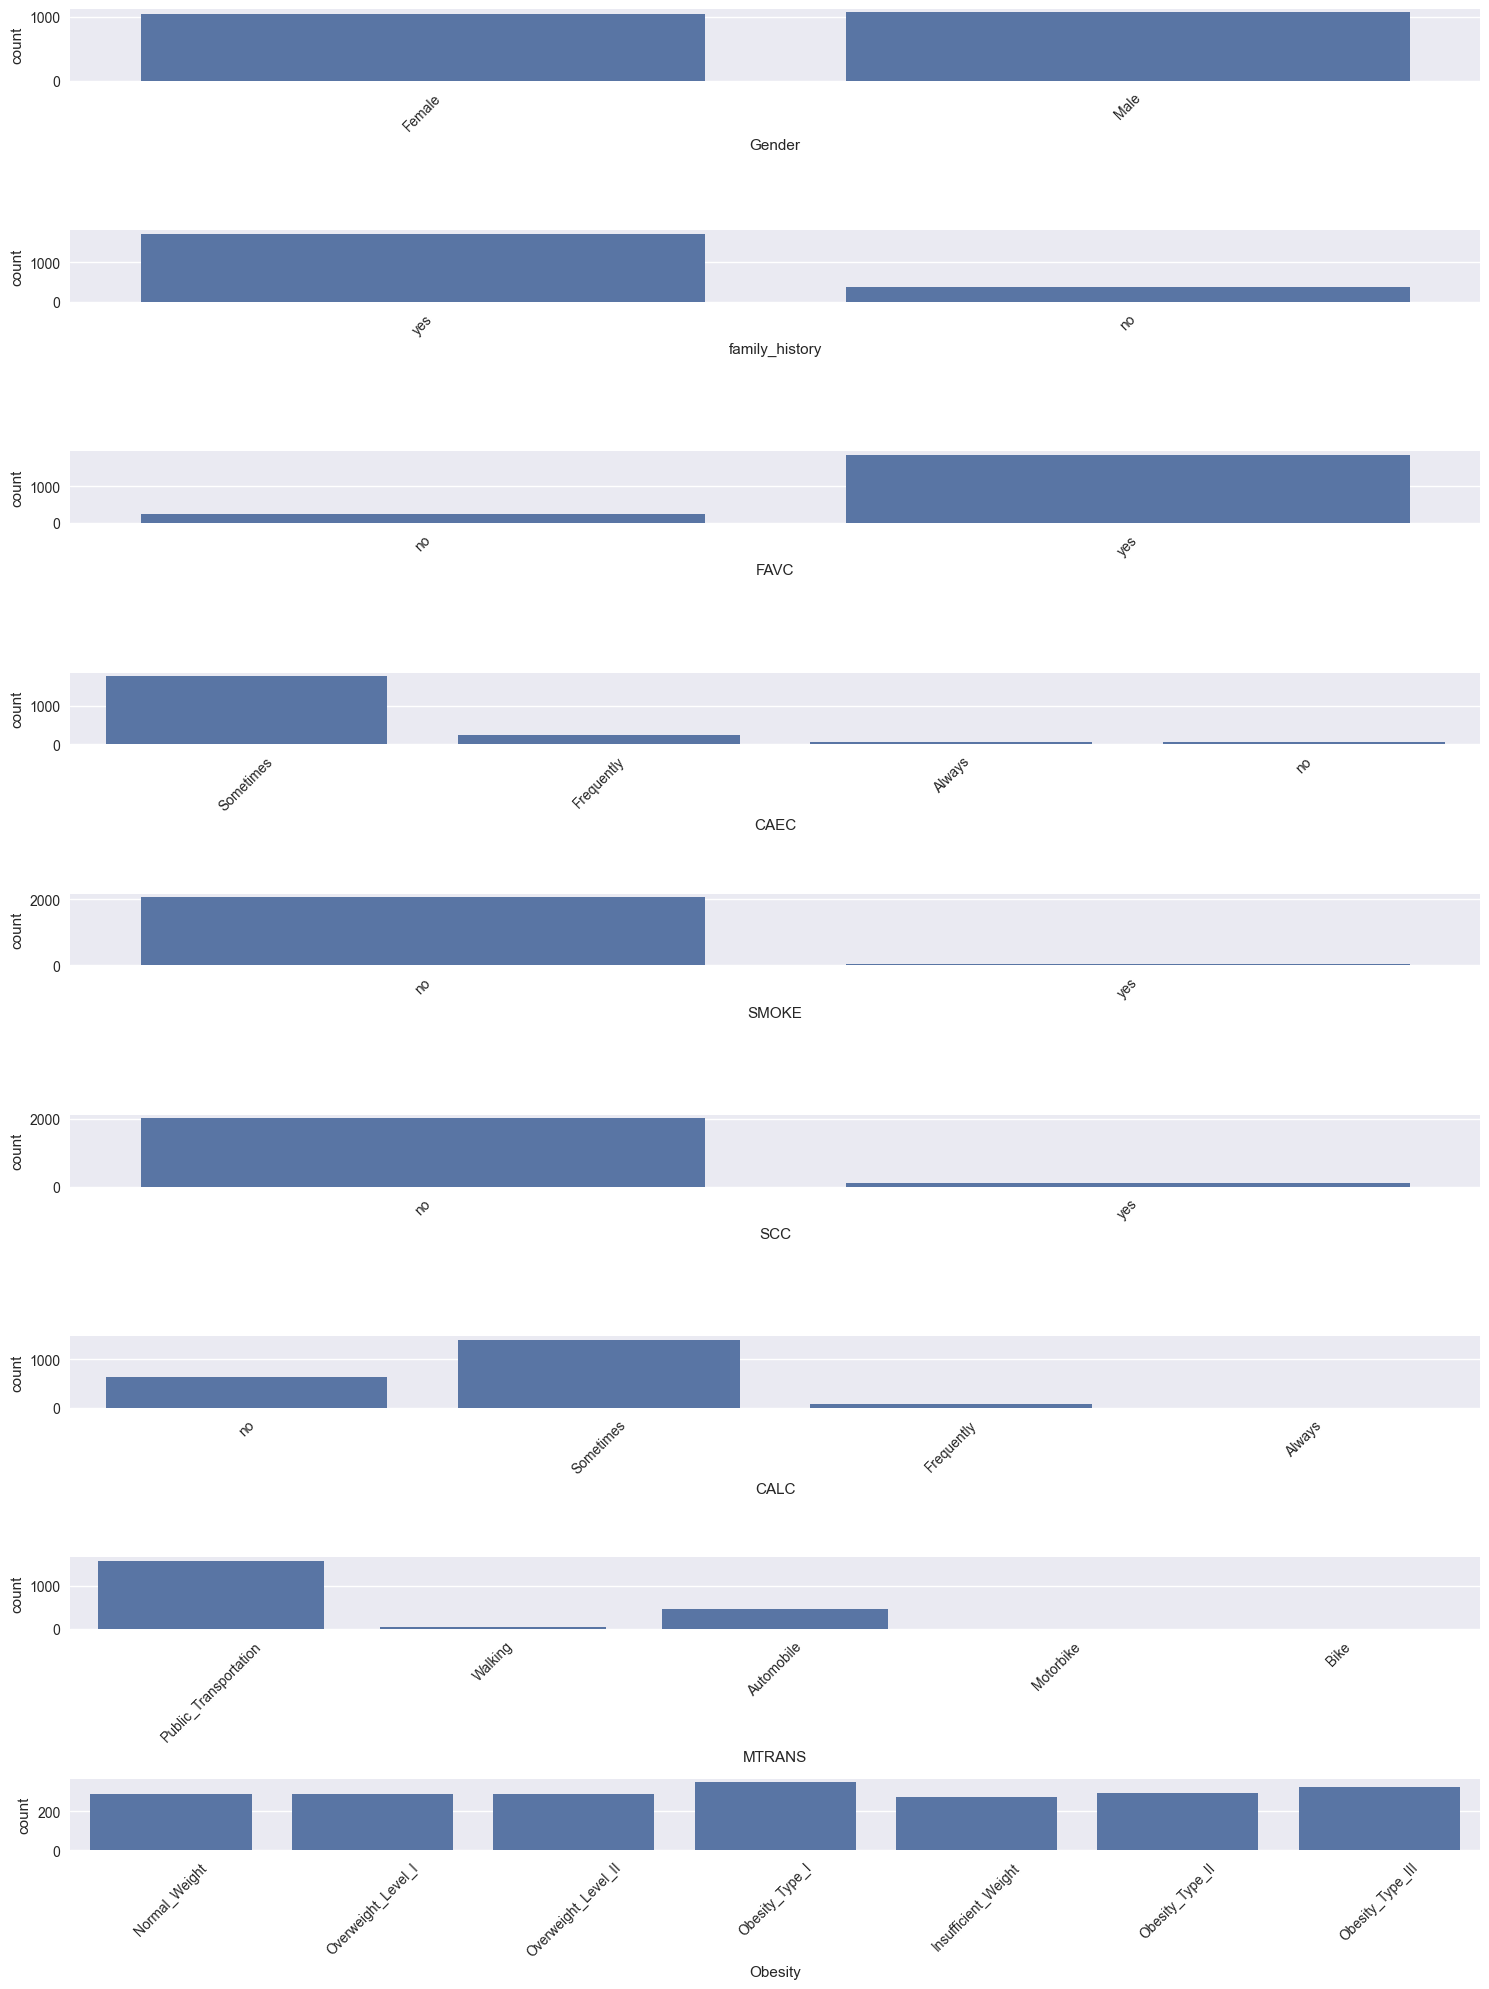

In [1354]:
plt.style.use('seaborn-v0_8')

cat_cols = df.select_dtypes(include=['object']).columns

plt.figure(figsize=(15, 20))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(len(cat_cols), 1, i)
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


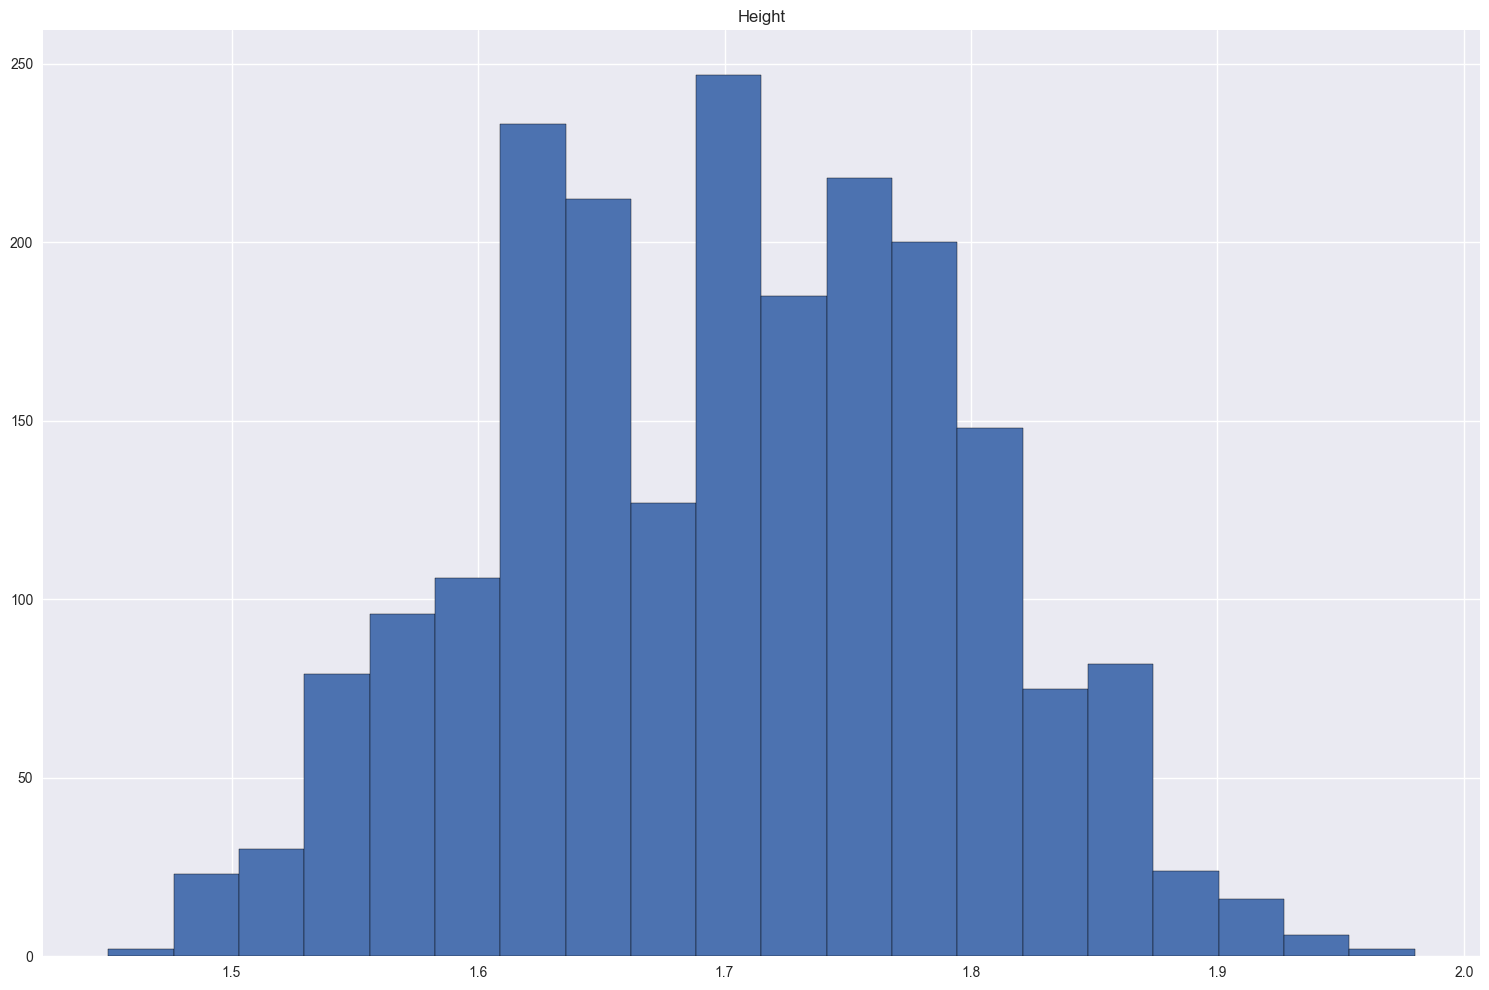

In [1355]:
num_cols = df.select_dtypes(include=['float64']).columns

df[num_cols].hist(figsize=(15,10), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()


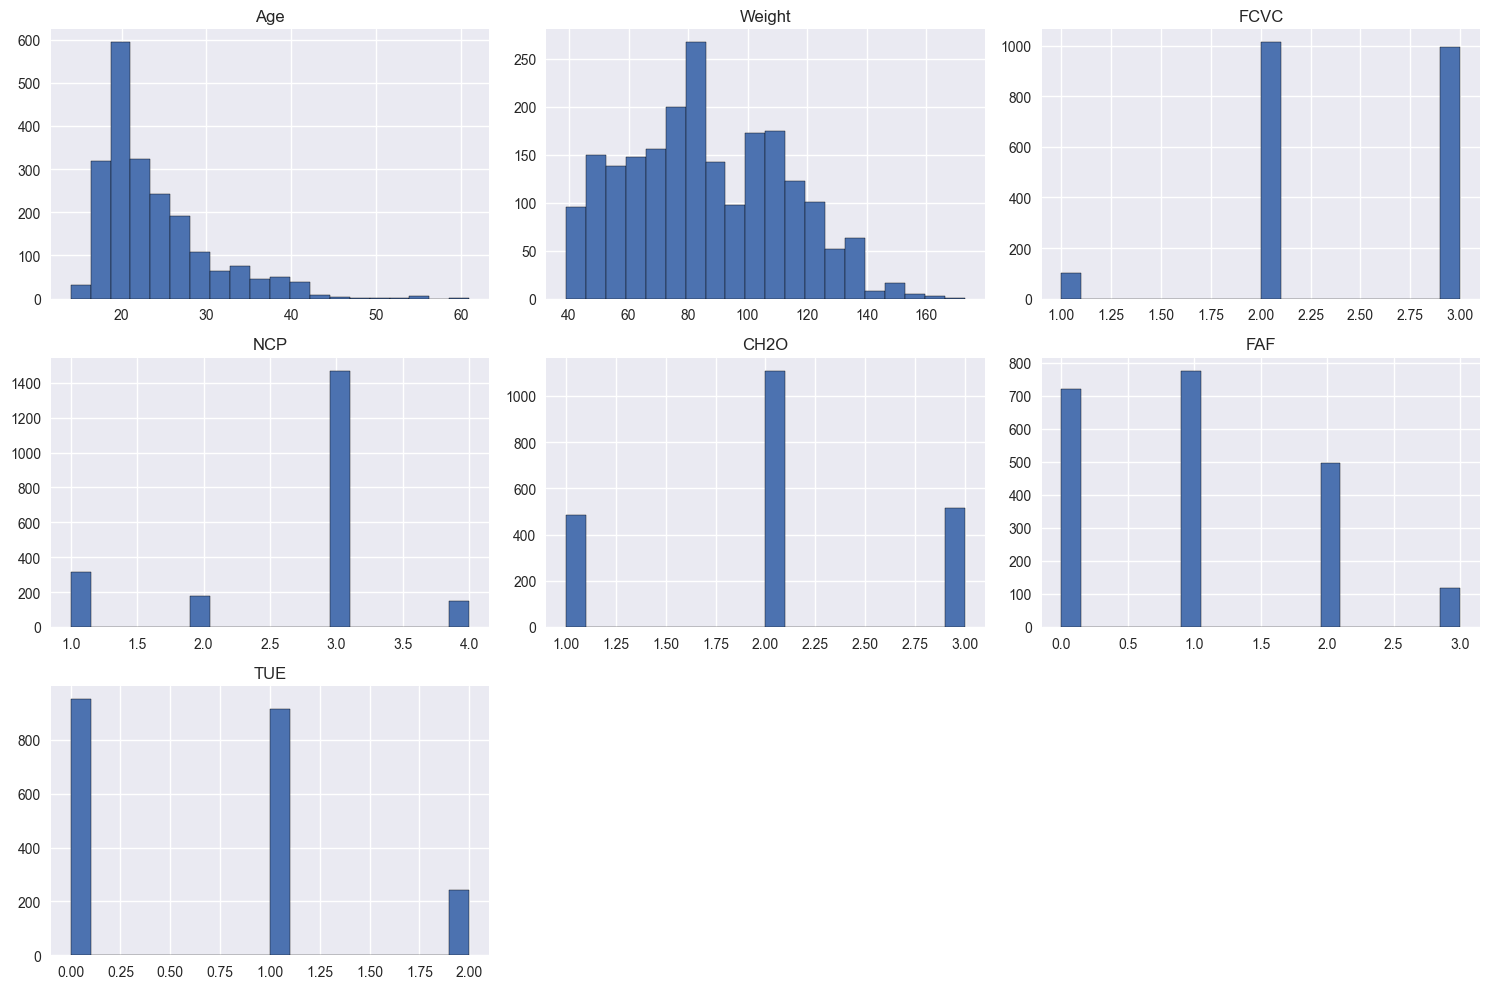

In [1356]:
num_cols = df.select_dtypes(include=['int64']).columns

df[num_cols].hist(figsize=(15,10), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

In [1357]:
X = df.drop('Obesity', axis=1)
y = df['Obesity']


In [1358]:
le = LabelEncoder()
y = le.fit_transform(y)


In [1359]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [1360]:
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns


In [1361]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [1362]:
model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5
)

In [1363]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

In [1364]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("Acurácias por fold:", cv_scores)
print("Acurácia média (CV):", cv_scores.mean())


Acurácias por fold: [0.9704142  0.96745562 0.95857988 0.95548961 0.96439169]
Acurácia média (CV): 0.9632662019559988


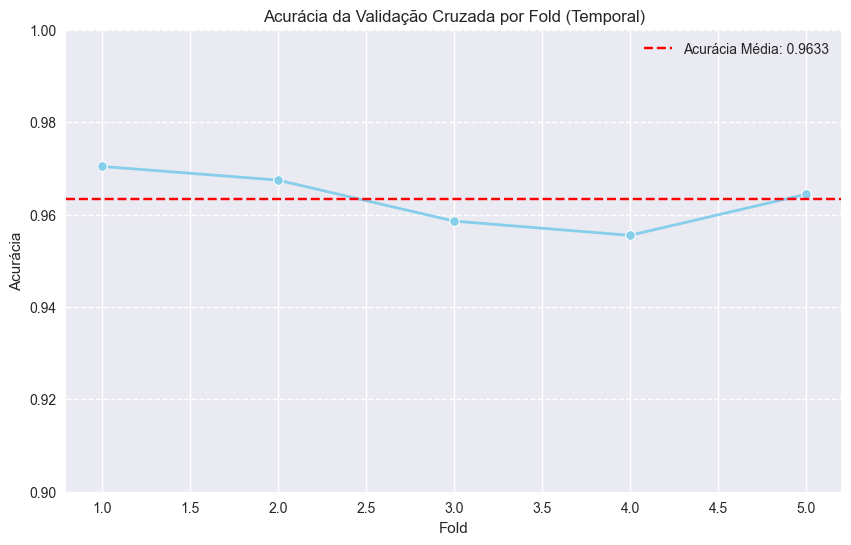

In [1365]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=np.arange(1, len(cv_scores) + 1), y=cv_scores, marker='o', color='skyblue', linewidth=2)
plt.axhline(cv_scores.mean(), color='r', linestyle='--', label=f'Acurácia Média: {cv_scores.mean():.4f}')
plt.title('Acurácia da Validação Cruzada por Fold (Temporal)')
plt.xlabel('Fold')
plt.ylabel('Acurácia')
plt.ylim(0.9, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()

In [1366]:
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [1367]:
y_pred = pipeline.predict(X_test)

print("Acurácia no teste:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))


Acurácia no teste: 0.9621749408983451

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        54
           1       0.91      0.90      0.90        58
           2       0.96      0.99      0.97        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.95      0.97      0.96        58
           6       0.98      0.97      0.97        58

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423



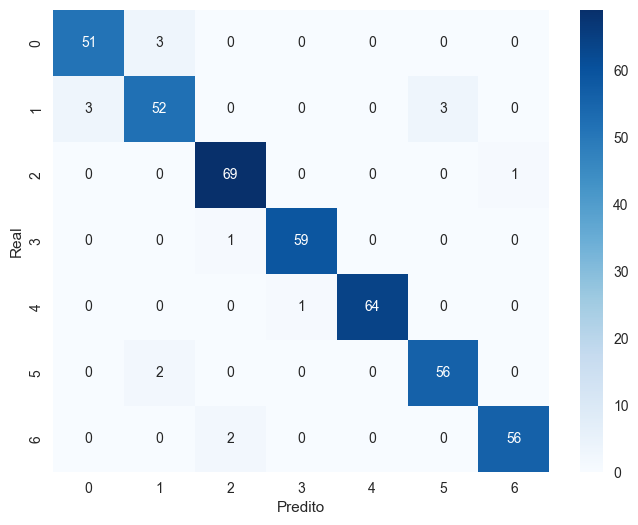

In [1368]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()


Importância das Features:
              Feature  Importance
8       Gender_Female    0.297880
2              Weight    0.124904
30     MTRANS_Walking    0.061635
15    CAEC_Frequently    0.059918
14        CAEC_Always    0.057647
25            CALC_no    0.047492
1              Height    0.044172
12            FAVC_no    0.043369
3                FCVC    0.040814
24     CALC_Sometimes    0.033490
0                 Age    0.022003
26  MTRANS_Automobile    0.020450
17            CAEC_no    0.018503
16     CAEC_Sometimes    0.017244
4                 NCP    0.015746


C:\Users\Evandro\AppData\Local\Temp\ipykernel_7040\1827473672.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')


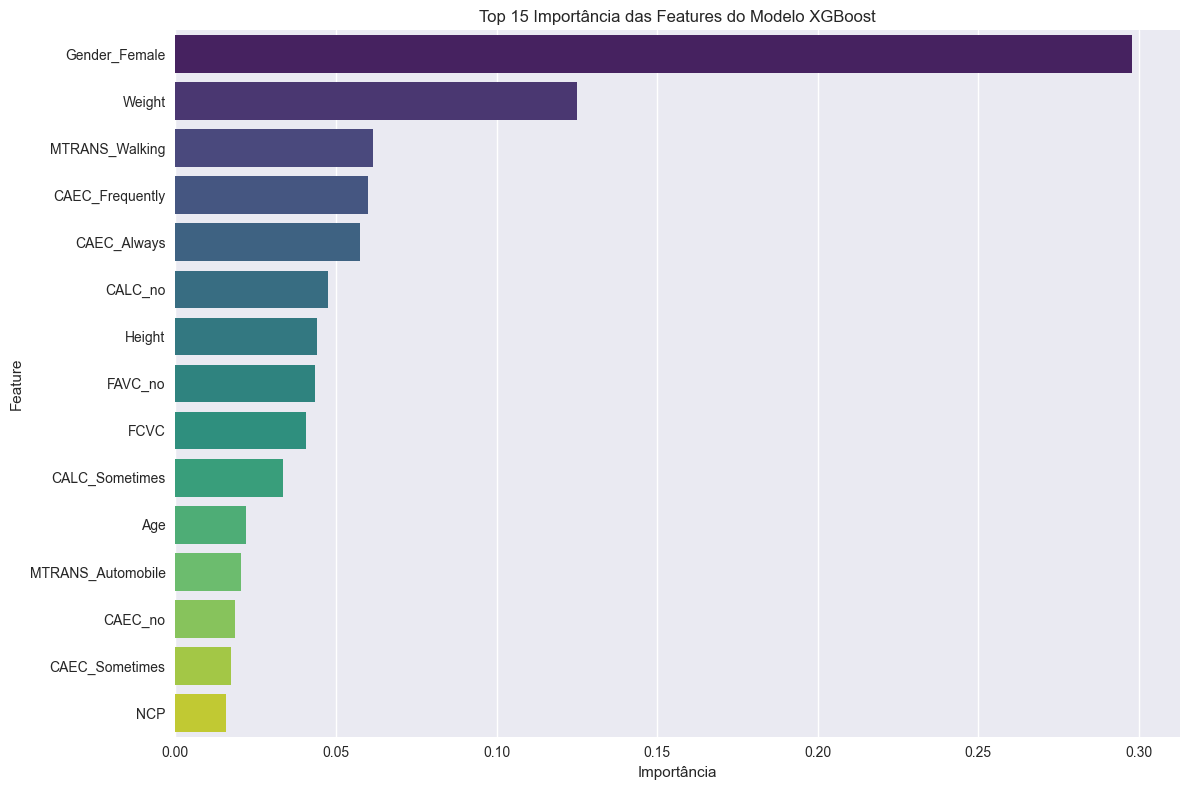

In [1369]:
feature_importances = pipeline.named_steps['classifier'].feature_importances_

num_features_out = num_cols.tolist()

cat_features_out = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()

all_features = num_features_out + cat_features_out

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Importância das Features:")
print(importance_df.head(15))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Importância das Features do Modelo XGBoost')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### JobLib

In [1370]:
if os.path.exists('modelo_obesity.joblib'):
    os.remove('modelo_obesity.joblib')
joblib.dump(pipeline, 'modelo_obesity.joblib')

print("Modelo salvo como 'modelo_obesity.joblib'")

Modelo salvo como 'modelo_obesity.joblib'


In [1371]:
if os.path.exists('label_encoder_obesity.joblib'):
    os.remove('label_encoder_obesity.joblib')
joblib.dump(le, 'label_encoder_obesity.joblib')

print("LabelEncoder salvo como 'label_encoder_obesity.joblib'")

LabelEncoder salvo como 'label_encoder_obesity.joblib'


In [1372]:
data = {
    'Gender': 'Female',
    'Age': 24,
    'Height': 1.65,
    'Weight': 80,
    'family_history': 'yes',
    'FAVC': 'yes',
    'FCVC': 2,
    'NCP': 3,
    'CAEC': 'Sometimes',
    'SMOKE': 'no',
    'CH2O': 2,
    'SCC': 'no',
    'FAF': 0,
    'TUE': 1,
    'CALC': 'Sometimes',
    'MTRANS': 'Public_Transportation'
}

import pandas as pd

input_df = pd.DataFrame([data])

import joblib

loaded_model = joblib.load('modelo_obesity.joblib')

prediction = loaded_model.predict(input_df)
prediction_proba = loaded_model.predict_proba(input_df)
confidence = max(prediction_proba[0]) * 100

le = joblib.load('label_encoder_obesity.joblib')

prediction_label = le.inverse_transform(prediction)

print(f"Prediction for the input data: {prediction_label[0]}")
print(f"Prediction for the input data percentage: ({confidence:.2f}%)")

Prediction for the input data: Overweight_Level_II
Prediction for the input data percentage: (95.81%)


In [1373]:
if "OBESITY" in prediction_label[0].upper() or "OVERWEIGHT" in prediction_label[0].upper():
    print("Obesidade: Sim")
else:
    print("Obesidade: Não")

Obesidade: Sim
